# Variational Generalized Nonlinear Mode Decomposition (VGNMD)

This notebook follows:

> Wang H., Chen S., Zhai W.  
> *Variational generalized nonlinear mode decomposition: Algorithm and applications.*  
> Mechanical Systems and Signal Processing, 206:110913, 2024.  
> https://doi.org/10.1016/j.ymssp.2023.110913

and the accompanying MATLAB toolbox (`VGNMD.m`, `ATFFC.m`, `MTDC.m`, `VOA.m`).

## Motivation

ACMD recovers **chirp** modes (time-varying instantaneous frequency, IF).  
GDMD recovers **dispersive** modes (frequency-varying group delay, GD).  
Neither alone can separate a **mixture** of both — a *generalized nonlinear signal* (GNS).

**VGNMD** does three things:

1. **ATFFC** — build a high-resolution, denoised TF map and **cluster** each mode;
2. **MTDC** — decide whether each cluster is chirp (type 1) or dispersive (type 2);
3. **VOA** — reconstruct with **ACMD** or **GDMD**, using the TF ridge as the initial IF / GD.

Applications in the paper include bat echolocation analysis and railway wheel/rail fault diagnosis.


## 1. Imports


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import VGNMD
from pysdkit._gdmd.vgnmd import (
    make_vgnmd_demo_signal,
    stft_vgnmd,
    atffc,
    mtdc,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
print(VGNMD())

Variational Generalized Nonlinear Mode Decomposition (VGNMD)


## 2. Generalized nonlinear signal model

A multi-component observation that mixes chirps and dispersive modes is written
schematically as

$$
s(t)=\sum_{i\in\mathcal{C}} a_i(t)\cos\!\Bigl(2\pi\int_0^t f_i(\lambda)\,\mathrm{d}\lambda+\phi_i\Bigr)
+\sum_{j\in\mathcal{D}} s_j^{\mathrm{(GD)}}(t)+\eta(t),
$$

- $\mathcal{C}$ — chirp modes characterised by IF $f_i(t)$ (ACMD model);
- $\mathcal{D}$ — dispersive modes whose Fourier transforms follow the GDM
  (GDMD / GDMD paper Eq. 5)

$$
S_j(f)=A_j(f)\,
\exp\!\left\{
-j\Bigl[2\pi\int_0^f \tau_j(\lambda)\,\mathrm{d}\lambda+\varphi_j\Bigr]
\right\}.
$$

Modes may be **discontinuous** in time or frequency; VGNMD only optimises on the
TF support detected by ATFFC.


## 3. Algorithm pipeline

### 3.1 ATFFC — adaptive TF fusion & clustering

For several STFT window lengths $W_i=f_s/(2i)$ ($i=1,\ldots,5$):

1. compute a normalised STFT;
2. soft-threshold with an adaptive level $\theta_i$;
3. **cluster** connected TF components (remove tiny noise blobs);
4. **fuse** with the previous map by intersection + element-wise max;
5. update $\theta_{i+1}$ from the penalty ratio of mean energies.

Output: a list of TF maps $\{\mathrm{Spec}_k\}$, one per mode.

### 3.2 MTDC — mode-type discrimination

On each cluster, extract a peak ridge along time, then (if needed) along frequency.
Compare average spacings of repeated ridge coordinates (`ad1`, `ad2`) and the
ridge slope ratio

$$
\mathrm{CR}=\left|\frac{\Delta f}{\Delta t}\right|.
$$

| Decision | Type | Initial feature |
|---|---|---|
| chirp-like ridge | `Type = 1` | IF samples $f(t)$ on the time support |
| dispersive-like ridge | `Type = 2` | GD samples $\tau(f)$ on the frequency support |

### 3.3 VOA — variational optimisation

**Chirp (type 1)** — ACMD on the truncated waveform $s(t)|_{t\in T_k}$:

$$
\min_{c,d,\bar f}
\bigl\{\|c''\|_2^2+\|d''\|_2^2+\alpha\|s-s_{\mathrm{chirp}}\|_2^2\bigr\},
$$

with demodulation kernels $\cos(2\pi\int\bar f)$, $\sin(2\pi\int\bar f)$.

**Dispersive (type 2)** — GDMD on the unilateral spectrum $S(f)|_{f\in F_k}$:

$$
\min_{G,\bar\tau}
\bigl\{\|G''\|_2^2+\alpha\|S-G\,e^{-j2\pi\int\bar\tau}\|_2^2\bigr\}.
$$

Default toolbox weights (also used here): $\alpha=10^{-4}$, $\beta=\upsilon=10^{-7}$.


## 4. MATLAB-style demo signal (`Test.m`)

Three chirps (full / left / right support) + four dispersive modes with
quadratic or oscillatory GDs, $f_s=1000\,\mathrm{Hz}$, $T=3\,\mathrm{s}$.


N = 3000, fs = 1000.0 Hz, true modes = 7


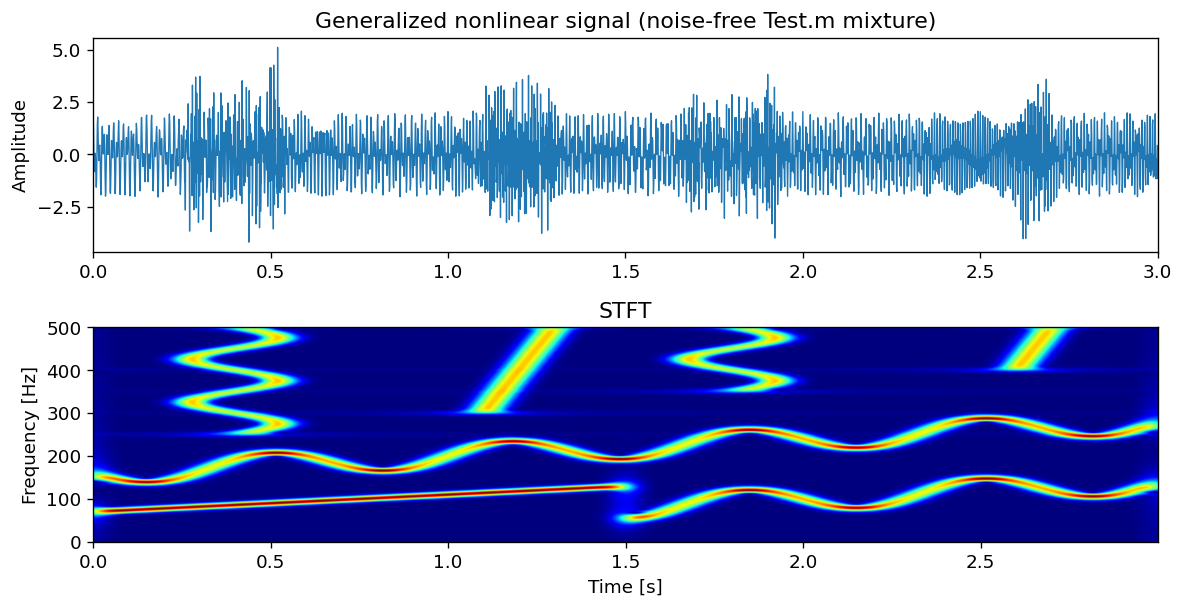

In [ ]:
demo = make_vgnmd_demo_signal(samp_freq=1000.0, noise_std=0.0)
fs = float(demo["fs"][0])
t = demo["t"]
signal = demo["signal"]
true_modes = demo["modes_true"]

print(f"N = {signal.size}, fs = {fs} Hz, true modes = {true_modes.shape[0]}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=False)
axes[0].plot(t, signal, color="C0", lw=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Generalized nonlinear signal (noise-free Test.m mixture)")
axes[0].set_xlim(0, 3)

# STFT overview
spec, f_stft = stft_vgnmd(signal, fs, win_len=fs / 4)
axes[1].imshow(
    spec,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], f_stft[0], f_stft[-1]],
    cmap="jet",
)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_title("STFT")
axes[1].set_ylim(0, fs / 2)
plt.tight_layout()
plt.show()

### 4.1 Ground-truth IF / GD curves

Blue: chirp IFs.  Other colours: dispersive GDs plotted as $(t=\tau(f),\,f)$.


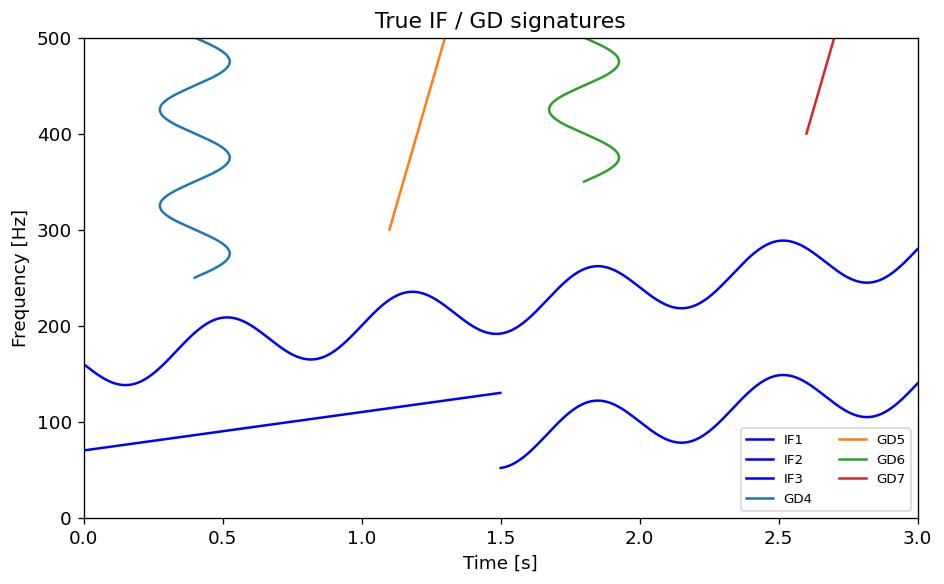

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, demo["if1"], "b-", lw=1.5, label="IF1")
ax.plot(demo["t1"], demo["if2"], "b-", lw=1.5, label="IF2")
ax.plot(demo["t2"], demo["if3"], "b-", lw=1.5, label="IF3")
ax.plot(demo["gd4"][~np.isnan(demo["gd4"])], demo["f42"], lw=1.5, label="GD4")
ax.plot(demo["gd5"][~np.isnan(demo["gd5"])], demo["f52"], lw=1.5, label="GD5")
ax.plot(demo["gd6"][~np.isnan(demo["gd6"])], demo["f62"], lw=1.5, label="GD6")
ax.plot(demo["gd7"][~np.isnan(demo["gd7"])], demo["f72"], lw=1.5, label="GD7")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_xlim(0, 3)
ax.set_ylim(0, 500)
ax.set_title("True IF / GD signatures")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 5. Run VGNMD

Equivalent to the MATLAB call:

```matlab
[Modet, Modef, Type, IIF_GD, EIF_GD, f, t] = VGNMD(Sign, SampFreq);
```


In [ ]:
decomp = VGNMD(alpha=1e-4, beta=1e-7, tol=1e-8, max_iter=200)
modes, modes_f, types, init_ridges, features, f, t_out = decomp.fit_transform(
    signal, fs, return_all=True
)

print(f"extracted modes: {modes.shape}")
print(f"types (1=chirp, 2=dispersive): {types}")
print(
    "reconstruction relative error:",
    np.linalg.norm(modes.sum(0) - signal) / np.linalg.norm(signal),
)

# match estimates to true modes by |correlation|
print("\nBest |corr| vs each true mode:")
for i, tr in enumerate(true_modes):
    corrs = [abs(np.corrcoef(modes[j], tr)[0, 1]) for j in range(modes.shape[0])]
    j = int(np.argmax(corrs))
    kind = "chirp" if types[j] == 1 else "dispersive"
    print(f"  true m{i+1} -> est m{j+1} ({kind}), |corr| = {corrs[j]:.3f}")

extracted modes: (7, 3000)
types (1=chirp, 2=dispersive): [1 1 1 2 2 2 2]
reconstruction relative error: 0.10203804312927145

Best |corr| vs each true mode:
  true m1 -> est m3 (chirp), |corr| = 0.997
  true m2 -> est m2 (chirp), |corr| = 0.995
  true m3 -> est m1 (chirp), |corr| = 0.995
  true m4 -> est m4 (dispersive), |corr| = 0.990
  true m5 -> est m5 (dispersive), |corr| = 0.999
  true m6 -> est m6 (dispersive), |corr| = 0.984
  true m7 -> est m7 (dispersive), |corr| = 0.997


### 5.1 ATFFC clusters (optional peek)

Visualise a few clustered TF maps that drive MTDC / VOA.


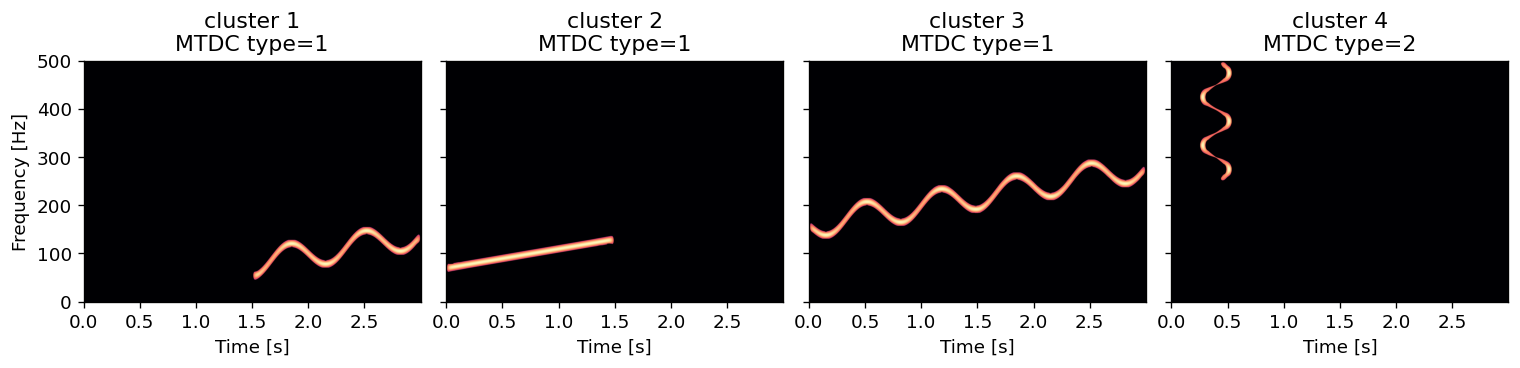

ATFFC returned 7 clusters


In [ ]:
clusters, f_clu = atffc(signal, fs, n_windows=5)
n_show = min(4, len(clusters))
fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2), sharey=True)
if n_show == 1:
    axes = [axes]
for ax, clu, k in zip(axes, clusters[:n_show], range(n_show)):
    ax.imshow(
        clu,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], f_clu[0], f_clu[-1]],
        cmap="magma",
    )
    mtype, _ = mtdc(clu)
    ax.set_title(f"cluster {k+1}\nMTDC type={mtype}")
    ax.set_xlabel("Time [s]")
axes[0].set_ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()
print(f"ATFFC returned {len(clusters)} clusters")

### 5.2 Estimated time-domain modes vs truth / error


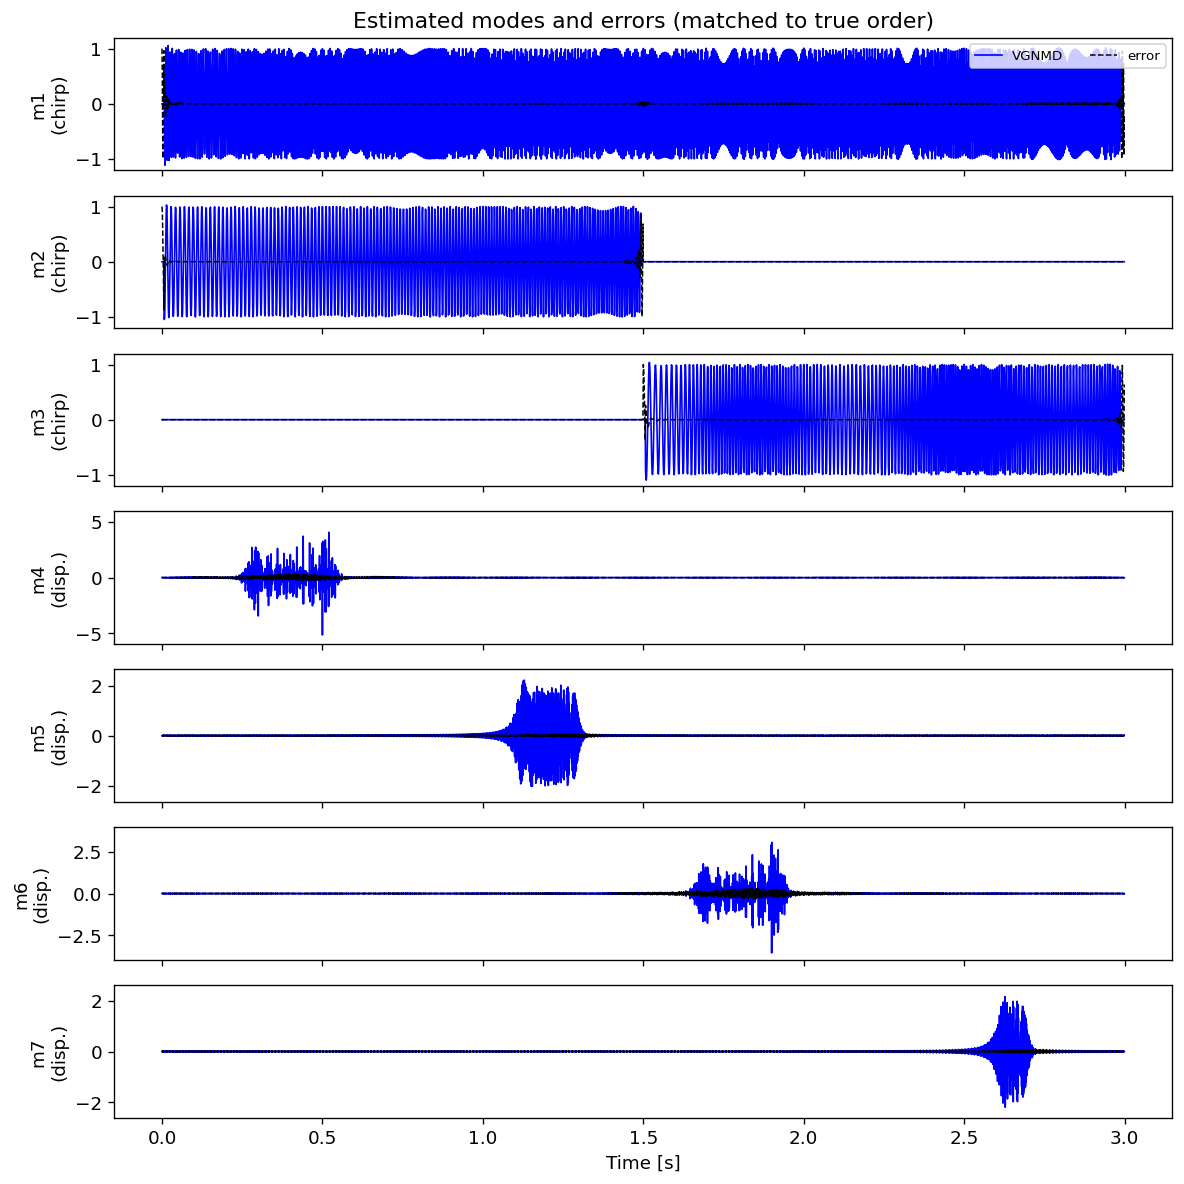

In [ ]:
# Order estimates to best match true modes for a fair visual comparison
order = []
used = set()
for tr in true_modes:
    corrs = [abs(np.corrcoef(modes[j], tr)[0, 1]) for j in range(modes.shape[0])]
    for j in np.argsort(corrs)[::-1]:
        if int(j) not in used:
            order.append(int(j))
            used.add(int(j))
            break

fig, axes = plt.subplots(7, 1, figsize=(10, 10), sharex=True)
for k in range(7):
    j = order[k] if k < len(order) else k
    axes[k].plot(t, modes[j], "b-", lw=1.0, label="VGNMD")
    axes[k].plot(t, true_modes[k] - modes[j], "k--", lw=0.9, label="error")
    kind = "chirp" if types[j] == 1 else "disp."
    axes[k].set_ylabel(f"m{k+1}\n({kind})")
    axes[k].set_ylim(np.array([-1, 1]) * (1.2 * np.max(np.abs(true_modes[k])) + 1e-6))
    if k == 0:
        axes[k].legend(loc="upper right", fontsize=8, ncol=2)
axes[-1].set_xlabel("Time [s]")
axes[0].set_title("Estimated modes and errors (matched to true order)")
plt.tight_layout()
plt.show()

### 5.3 Estimated IF / GD overlays

For chirp modes, `features[k]` stores the refined IF on the time axis.  
For dispersive modes, it stores the refined GD on the frequency axis of the STFT.


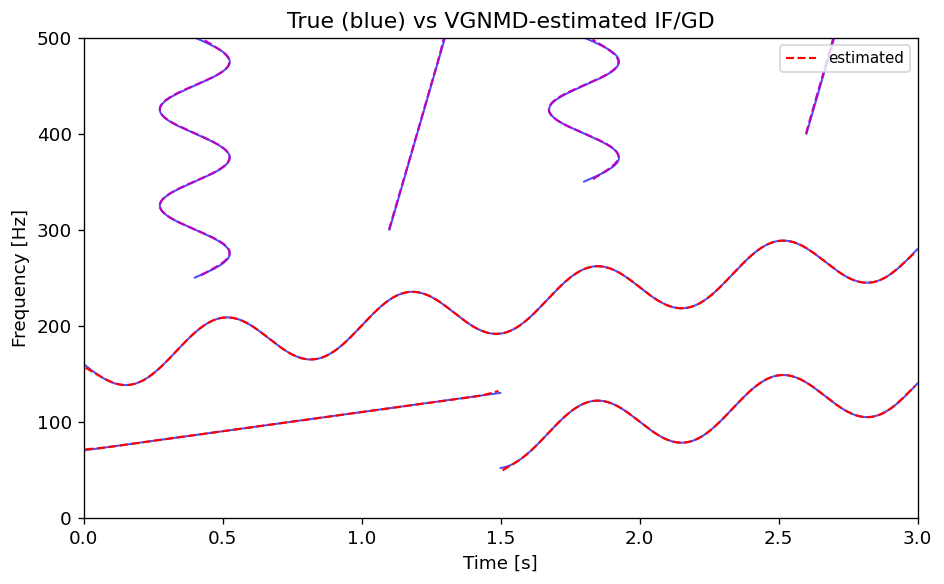

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
# true references
ax.plot(t, demo["if1"], "b-", lw=1.2, alpha=0.7)
ax.plot(demo["t1"], demo["if2"], "b-", lw=1.2, alpha=0.7)
ax.plot(demo["t2"], demo["if3"], "b-", lw=1.2, alpha=0.7)
for gd, fq in [
    (demo["gd4"], demo["f42"]),
    (demo["gd5"], demo["f52"]),
    (demo["gd6"], demo["f62"]),
    (demo["gd7"], demo["f72"]),
]:
    mask = ~np.isnan(gd)
    ax.plot(gd[mask], fq, "b-", lw=1.2, alpha=0.7)

for k, (typ, feat) in enumerate(zip(types, features)):
    if typ == 1:
        support = np.flatnonzero(np.abs(feat) > 0)
        if support.size:
            ax.plot(
                t[support],
                feat[support],
                "r--",
                lw=1.3,
                label="estimated" if k == 0 else None,
            )
    else:
        support = np.flatnonzero(np.abs(feat) > 0)
        if support.size:
            ax.plot(
                feat[support],
                f[support],
                "m--",
                lw=1.3,
                label="estimated GD" if k == 0 else None,
            )

ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_xlim(0, 3)
ax.set_ylim(0, 500)
ax.set_title("True (blue) vs VGNMD-estimated IF/GD")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Noisy case (optional)

The MATLAB demo adds Gaussian noise with std $0.4$.  ATFFC is designed to keep
clusters stable under moderate noise.


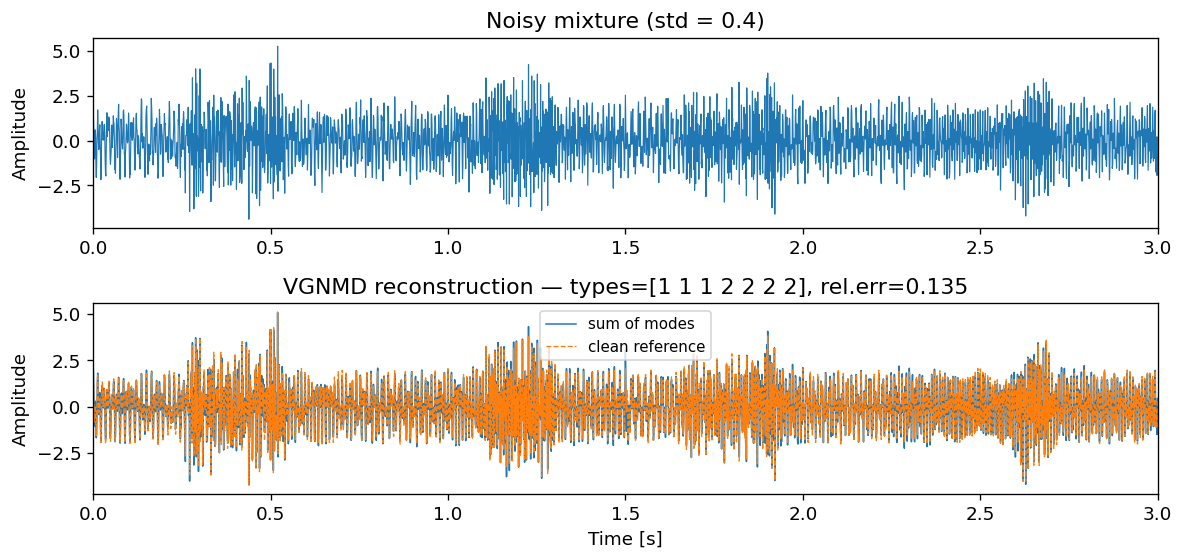

In [ ]:
demo_n = make_vgnmd_demo_signal(
    samp_freq=1000.0, noise_std=0.4, rng=np.random.default_rng(0)
)
sign = demo_n["signal"]

decomp_n = VGNMD(alpha=1e-4, beta=1e-7, tol=1e-6, max_iter=120)
modes_n, _, types_n, *_ = decomp_n.fit_transform(sign, fs, return_all=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 4.8))
axes[0].plot(t, sign, lw=0.7)
axes[0].set_title("Noisy mixture (std = 0.4)")
axes[0].set_xlim(0, 3)
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, modes_n.sum(0), lw=0.9, label="sum of modes")
axes[1].plot(t, demo_n["clean"], "--", lw=0.8, label="clean reference")
axes[1].set_xlim(0, 3)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].legend(fontsize=9)
axes[1].set_title(
    f"VGNMD reconstruction — types={types_n}, "
    f"rel.err={np.linalg.norm(modes_n.sum(0)-demo_n['clean'])/np.linalg.norm(demo_n['clean']):.3f}"
)
plt.tight_layout()
plt.show()

## 7. Parameter cheat-sheet

| PySDKit / MATLAB | Role |
|---|---|
| `alpha` ($10^{-4}$) | ACMD / GDMD bandwidth weight |
| `beta` ($10^{-7}$) | IF / GD increment smoothness |
| `tol` | VOA stopping tolerance |
| `n_windows` (5) | number of STFT windows in ATFFC |
| `min_frac` (0.001) | drop TF blobs smaller than this fraction of the plane |
| `Type = 1 / 2` | chirp (ACMD) / dispersive (GDMD) |

**Practical tips**

- Provide a realistic `fs`; ATFFC window lengths scale with $f_s/(2i)$.
- For very strong noise, slightly raise the effective threshold by checking ATFFC
  clusters before trusting MTDC.
- Discontinuous modes are handled naturally because VOA only runs on the ridge
  support returned by ATFFC.
